# Credit Card Fraud Detection

### Libraries and Dataset Import
We import the required libraries and load the training dataset. A quick look at the first rows gives an overview of the available features.

In [71]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score,average_precision_score,ConfusionMatrixDisplay,RocCurveDisplay,PrecisionRecallDisplay,precision_recall_curve


In [2]:
df = pd.read_csv("archive/fraudTrain.csv", index_col="Unnamed: 0")
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Exploratory Data Analysis

We begin by familiarizing ourselves with the dataset: inspecting its shape and checking for missing or duplicate values. We also use `info()` to verify the data type of each column.

In [3]:
print(f"Dataset size: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate values: {df.duplicated().sum()}")

Dataset size: (1296675, 22)
Missing values: 0
Duplicate values: 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

The dataset contains no missing or duplicate values. Among the 22 features, all data types are correctly inferred except for the two temporal columns `trans_date_trans_time` and `dob`, which must be converted to datetime before any further processing.

In [5]:
df["trans_date_trans_time"]=pd.to_datetime(df["trans_date_trans_time"])
df["dob"]=pd.to_datetime(df["dob"])

We begin the EDA by examining the target variable `is_fraud` to assess the distribution of fraudulent transactions.

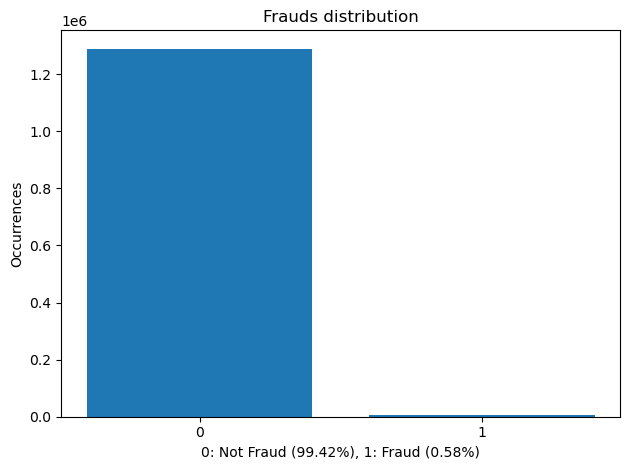

In [6]:
frauds=df["is_fraud"].value_counts()
fig,ax=plt.subplots()
ax.bar(frauds.index,frauds.values)
ax.set_xticks(frauds.index)
ax.set_title("Frauds distribution")
ax.set_xlabel(f"0: Not Fraud ({round(frauds[0]/frauds.sum()*100,2)}%), 1: Fraud ({round(frauds[1]/frauds.sum()*100,2)}%)")
ax.set_ylabel("Occurrences")

plt.tight_layout()
plt.show()

As expected, fraudulent transactions represent a negligible fraction of the dataset (~0.58%). This severe class imbalance means we are not dealing with a standard binary classification problem, but rather an anomaly detection task. We proceed by inspecting `trans_date_trans_time` to identify any temporal patterns in fraudulent activity.

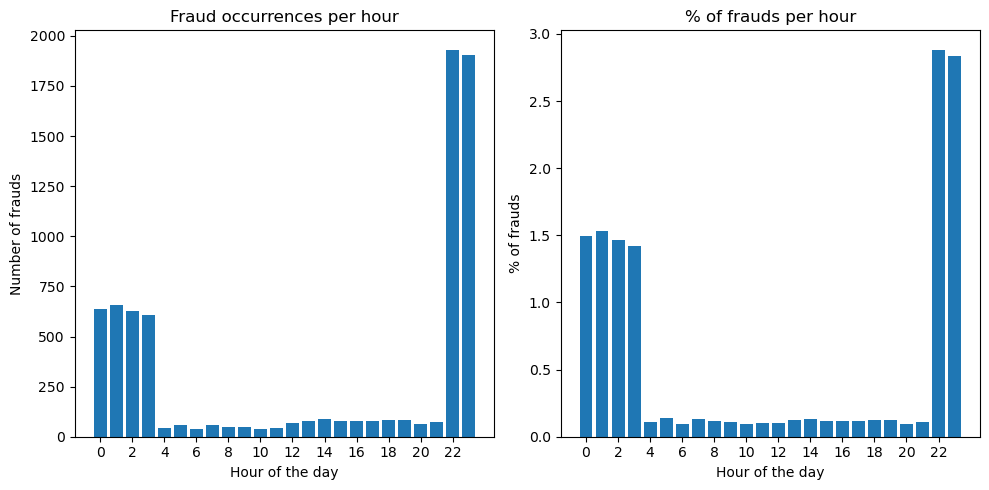

In [40]:
trans_hour=df["trans_date_trans_time"].dt.hour
fraud_hour=df["trans_date_trans_time"][df["is_fraud"]==1].dt.hour
trans_hour_counts=trans_hour.value_counts().sort_index()
fraud_hour_counts=fraud_hour.value_counts().sort_index()
perc_frauds=fraud_hour_counts/trans_hour_counts*100

fig,ax=plt.subplots(ncols=2, figsize=(10,5))
ax[0].bar(np.arange(24),fraud_hour_counts)
ax[0].set_xticks(np.arange(0,24,2))
ax[0].set_xlabel("Hour of the day")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Fraud occurrences per hour")

ax[1].bar(np.arange(24),perc_frauds)
ax[1].set_xticks(np.arange(0,24,2))
ax[1].set_xlabel("Hour of the day")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("% of frauds per hour")

plt.tight_layout()
plt.show()


The first important signal emerges clearly: fraud is strongly concentrated between 10 PM and 3 AM. This holds both in absolute count and as a percentage of total transactions per hour, ruling out any confound from varying transaction volumes throughout the day.

We further decompose the temporal dimension to check whether the day of the week, the day of the month, and the month of the year carry additional signal.

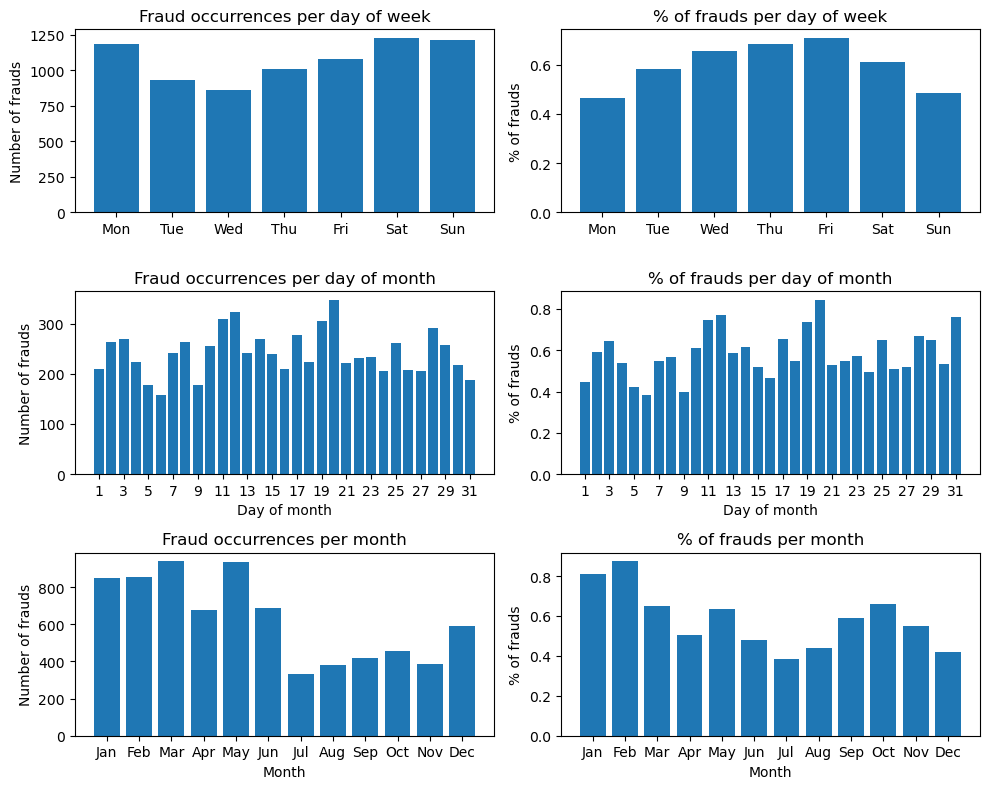

In [25]:
fig, ax = plt.subplots(nrows=3, ncols=2,figsize=(10,8))

trans_dow = df["trans_date_trans_time"].dt.dayofweek
fraud_dow = df["trans_date_trans_time"][df["is_fraud"]==1].dt.dayofweek
trans_dow_counts = trans_dow.value_counts().sort_index()
fraud_dow_counts = fraud_dow.value_counts().sort_index()
perc_frauds_dow = (fraud_dow_counts / trans_dow_counts) * 100

dow = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

ax[0, 0].bar(trans_dow_counts.index, fraud_dow_counts)
ax[0, 0].set_xticks(range(7))
ax[0, 0].set_xticklabels(dow)
ax[0, 0].set_ylabel("Number of frauds")
ax[0, 0].set_title("Fraud occurrences per day of week")

ax[0, 1].bar(trans_dow_counts.index, perc_frauds_dow)
ax[0, 1].set_xticks(range(7))
ax[0, 1].set_xticklabels(dow)
ax[0, 1].set_ylabel("% of frauds")
ax[0, 1].set_title("% of frauds per day of week")

trans_dom = df["trans_date_trans_time"].dt.day
fraud_dom = df["trans_date_trans_time"][df["is_fraud"]==1].dt.day
trans_dom_counts = trans_dom.value_counts().sort_index()
fraud_dom_counts = fraud_dom.value_counts().sort_index()
perc_frauds_dom = (fraud_dom_counts / trans_dom_counts) * 100

ax[1, 0].bar(trans_dom_counts.index, fraud_dom_counts)
ax[1, 0].set_xticks(range(1, 32, 2))
ax[1, 0].set_xlabel("Day of month")
ax[1, 0].set_ylabel("Number of frauds")
ax[1, 0].set_title("Fraud occurrences per day of month")

ax[1, 1].bar(trans_dom_counts.index, perc_frauds_dom)
ax[1, 1].set_xticks(range(1, 32, 2))
ax[1, 1].set_xlabel("Day of month")
ax[1, 1].set_ylabel("% of frauds")
ax[1, 1].set_title("% of frauds per day of month")

trans_month = df["trans_date_trans_time"].dt.month
fraud_month = df["trans_date_trans_time"][df["is_fraud"] == 1].dt.month
trans_month_counts = trans_month.value_counts().sort_index()
fraud_month_counts = fraud_month.value_counts().sort_index()
perc_frauds_month = (fraud_month_counts / trans_month_counts) * 100

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


ax[2,0].bar(fraud_month_counts.index, fraud_month_counts.values)
ax[2,0].set_xticks(range(1, 13))
ax[2,0].set_xticklabels(months)
ax[2,0].set_xlabel("Month")
ax[2,0].set_ylabel("Number of frauds")
ax[2,0].set_title("Fraud occurrences per month")

ax[2,1].bar(perc_frauds_month.index, perc_frauds_month.values)
ax[2,1].set_xticks(range(1, 13))
ax[2,1].set_xticklabels(months)
ax[2,1].set_xlabel("Month")
ax[2,1].set_ylabel("% of frauds")
ax[2,1].set_title("% of frauds per month")

plt.tight_layout()
plt.show()

Broadening the temporal granularity yields no additional signal. Neither the day of the week, the day of the month, nor the month of the year show a consistent pattern in the fraud rate. The hour of the day remains the only informative temporal feature and will be extracted during feature engineering.

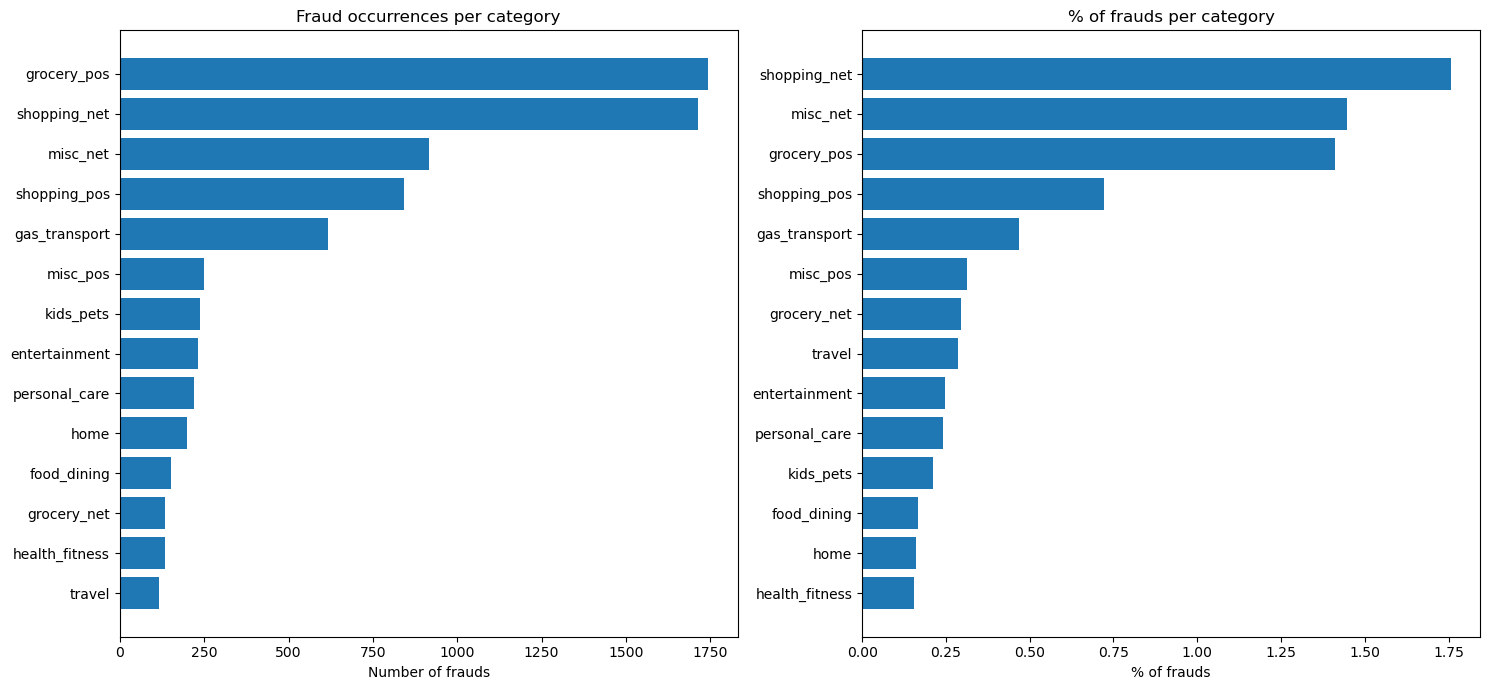

In [47]:
trans_cat = df["category"].value_counts()
fraud_cat = df[df["is_fraud"] == 1]["category"].value_counts()
perc_frauds_cat = (fraud_cat / trans_cat * 100).dropna().sort_values(ascending=True)
fraud_cat_sorted = fraud_cat.sort_values(ascending=True)

fig, ax = plt.subplots(ncols=2, figsize=(15, 7))

ax[0].barh(fraud_cat_sorted.index, fraud_cat_sorted.values)
ax[0].set_xlabel("Number of frauds")
ax[0].set_title("Fraud occurrences per category")

ax[1].barh(perc_frauds_cat.index, perc_frauds_cat.values)
ax[1].set_xlabel("% of frauds")
ax[1].set_title("% of frauds per category")

plt.tight_layout()
plt.show()

A clear signal emerges: while the most represented categories in absolute terms are everyday ones such as groceries and shopping, the fraud rate is dominated by online transactions — those belonging to categories ending with the *_net* suffix.

Before moving to the next feature, we briefly inspect `merchant` to verify whether it carries any signal beyond what `category` already captures.

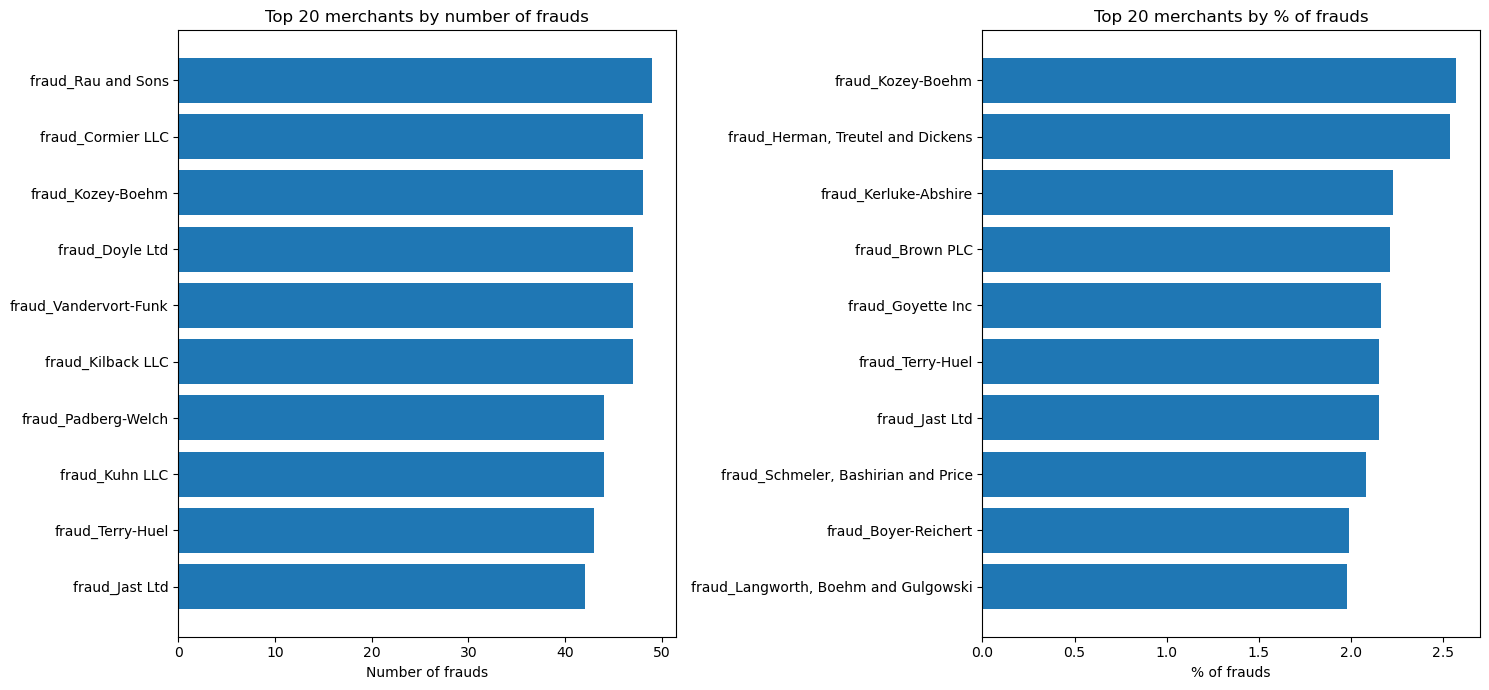

In [49]:
trans_merch = df['merchant'].value_counts()
fraud_merch = df[df['is_fraud'] == 1]['merchant'].value_counts()

top20_abs = fraud_merch.sort_values(ascending=True).tail(10)
top20_perc = (fraud_merch / trans_merch * 100).dropna().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(ncols=2, figsize=(15, 7))

ax[0].barh(top20_abs.index, top20_abs.values)
ax[0].set_xlabel("Number of frauds")
ax[0].set_title("Top 20 merchants by number of frauds")

ax[1].barh(top20_perc.index, top20_perc.values)
ax[1].set_xlabel("% of frauds")
ax[1].set_title("Top 20 merchants by % of frauds")

plt.tight_layout()
plt.show()

The `merchant` feature has approximately 700 unique values. We limit the analysis to the top 20 merchants by absolute fraud count and by fraud rate, following the same dual-perspective approach used throughout the EDA.

In [ ]:
trans_merch = df['merchant'].value_counts()
fraud_merch = df[df['is_fraud'] == 1]['merchant'].value_counts()

top20_abs = fraud_merch.sort_values(ascending=True).tail(20)
top20_perc = (fraud_merch / trans_merch * 100).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(ncols=2, figsize=(16, 8))

ax[0].barh(top20_abs.index, top20_abs.values)
ax[0].set_xlabel("Number of frauds")
ax[0].set_title("Top 20 merchants by number of frauds")

ax[1].barh(top20_perc.index, top20_perc.values)
ax[1].set_xlabel("% of frauds")
ax[1].set_title("Top 20 merchants by % of frauds")

plt.tight_layout()
plt.show()

No consistent signal emerges from the merchant-level analysis. The merchants with the highest fraud rates are those with very few total transactions — a statistical artefact rather than a genuine pattern. With ~700 unique values and no signal beyond what `category` already captures at cardinality 14, `merchant` will be dropped.

We now turn to the `amt` feature, which represents the transaction amount in dollars.

Stats legit transactions
count    1.289169e+06
mean     6.766711e+01
std      1.540080e+02
min      1.000000e+00
25%      9.610000e+00
50%      4.728000e+01
75%      8.254000e+01
max      2.894890e+04
Name: amt, dtype: float64

Stats frauds
count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64


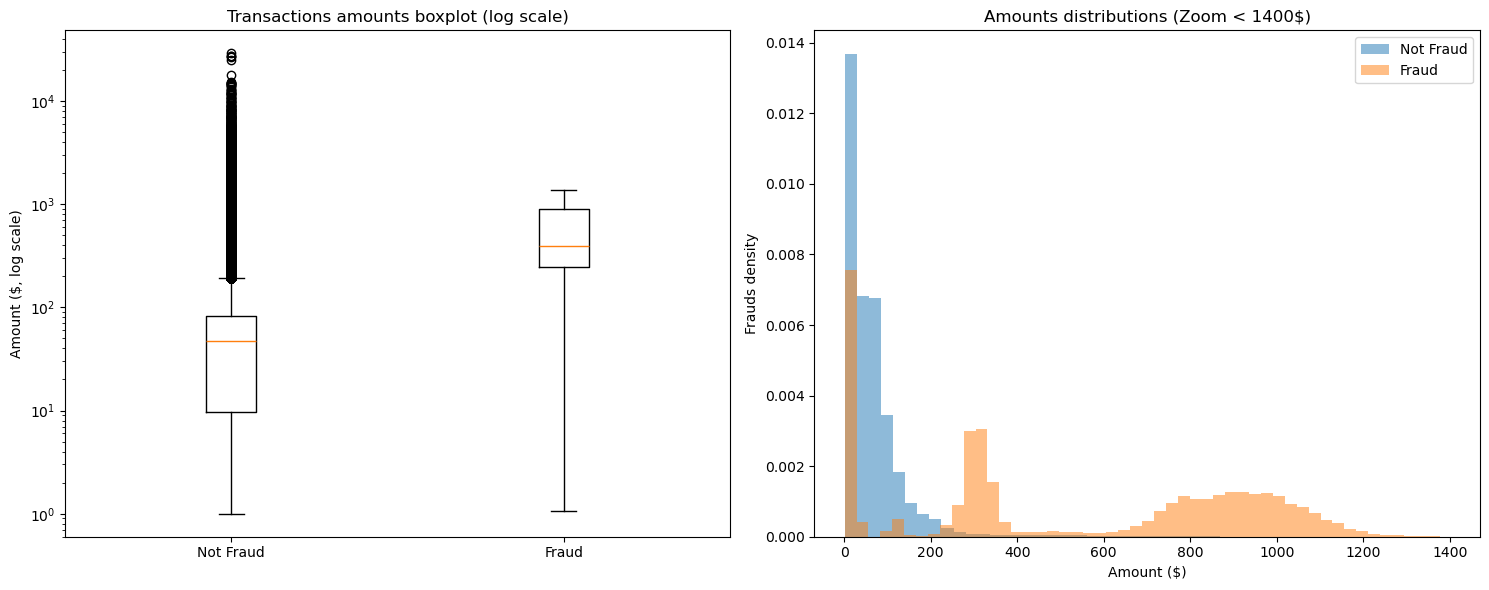

In [10]:
print("Stats legit transactions")
print(df[df['is_fraud'] == 0]['amt'].describe())
print("\nStats frauds")
print(df[df['is_fraud'] == 1]['amt'].describe())

fig, ax = plt.subplots(ncols=2, figsize=(15, 6))

ax[0].boxplot([df[df["is_fraud"]==0]["amt"], df[df["is_fraud"]==1]["amt"]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_yscale("log") 
ax[0].set_ylabel("Amount ($, log scale)")
ax[0].set_title("Transactions amounts boxplot (log scale)")

ax[1].hist(df[(df["is_fraud"]==0) & (df["amt"] < 1400)]["amt"], bins=50, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(df[(df["is_fraud"]==1) & (df["amt"] < 1400)]["amt"], bins=50, alpha=0.5, label="Fraud", density=True)
ax[1].set_xlabel("Amount ($)")
ax[1].set_ylabel("Frauds density")
ax[1].set_title("Amounts distributions (Zoom < 1400$)")
ax[1].legend()

plt.tight_layout()
plt.show()

The printed statistics, boxplots, and empirical distributions converge on a clear picture: legitimate transactions are concentrated in the range of tens of dollars, with a long but thin tail of occasional large purchases. Fraudulent transactions show a distinctly different profile — fraudsters typically begin with small test charges to verify the card is active, then follow up with larger transactions in the hundreds of dollars.

We next examine `dob` to check whether the cardholder's age is associated with fraud likelihood.

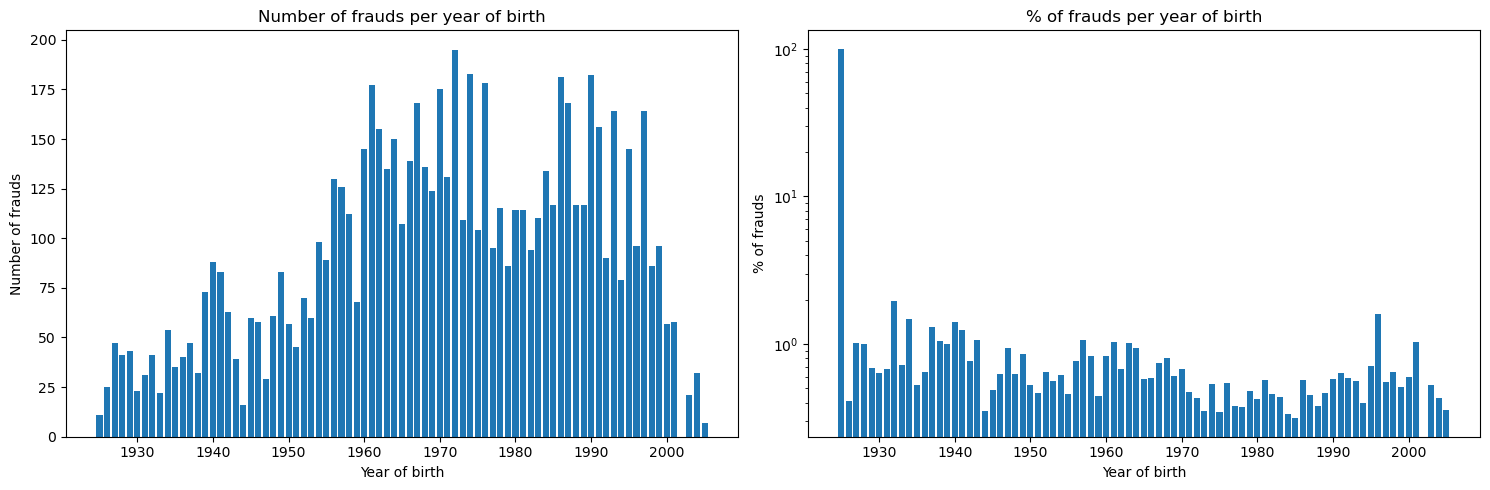

In [41]:
trans_yob = df["dob"].dt.year
fraud_yob = df[df["is_fraud"] == 1]["dob"].dt.year
trans_yob_counts = trans_yob.value_counts().sort_index()
fraud_yob_counts = fraud_yob.value_counts().sort_index()
perc_frauds_yob = (fraud_yob_counts / trans_yob_counts) * 100

fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

ax[0].bar(fraud_yob_counts.index, fraud_yob_counts.values)
ax[0].set_xlabel("Year of birth")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Number of frauds per year of birth")


ax[1].bar(perc_frauds_yob.index, perc_frauds_yob.values)
ax[1].set_xlabel("Year of birth")
ax[1].set_ylabel("% of frauds")
ax[1].set_yscale("log")
ax[1].set_title("% of frauds per year of birth")


plt.tight_layout()
plt.show()

In [12]:
df[df["dob"].dt.year==1925][["cc_num","is_fraud"]].value_counts()

cc_num            is_fraud
4492677353108006  1           11
Name: count, dtype: int64

The absolute fraud count by birth year simply reflects the active population (roughly those born between 1960 and 2000), with no age-related pattern in the fraud rate. The spike at 1925 appears anomalous but is entirely explained by a single compromised card — confirmed by the lookup above. Age carries no predictive signal and `dob` will be dropped.

We now check whether the distance between the cardholder's home location (`lat`, `long`) and the merchant's location (`merch_lat`, `merch_long`) is informative.

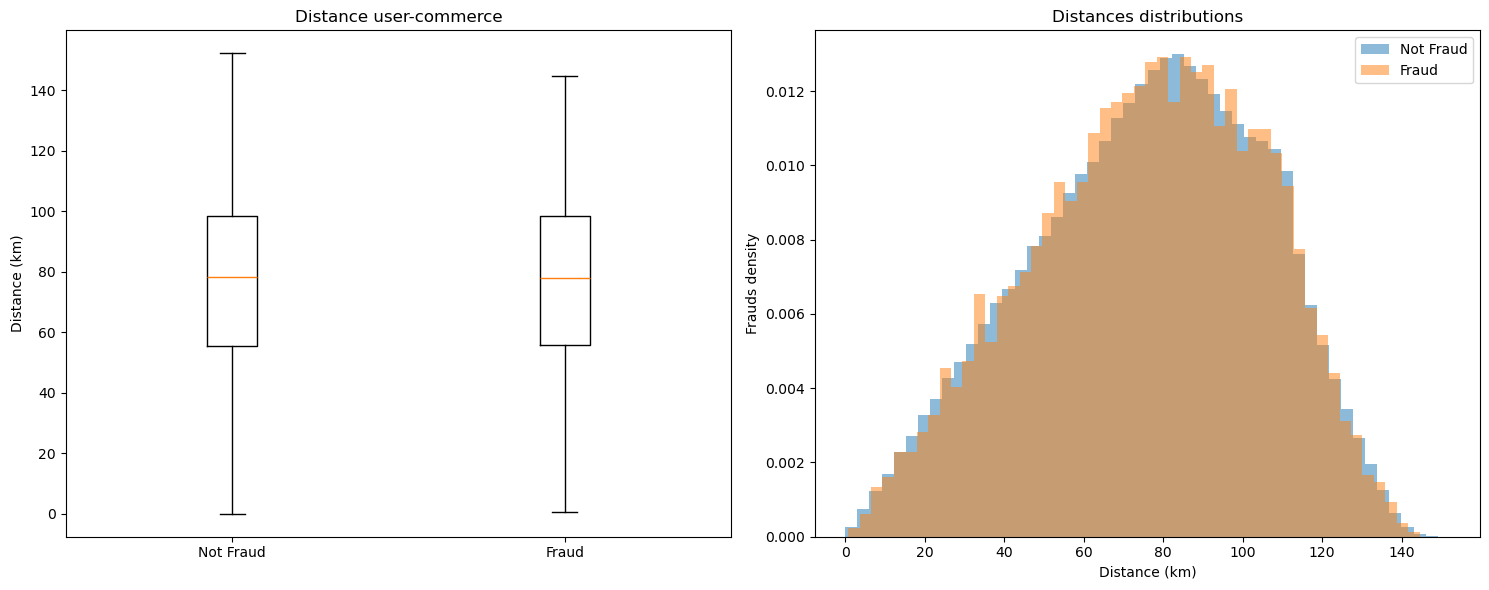

In [13]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    d=R*c
    return d

dist_km = haversine_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

fig, ax = plt.subplots(ncols=2, figsize=(15, 6))

ax[0].boxplot([dist_km[df["is_fraud"]==0], dist_km[df["is_fraud"]==1]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_ylabel("Distance (km)")
ax[0].set_title("Distance user-commerce")

ax[1].hist(dist_km[df["is_fraud"]==0], bins=50, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(dist_km[df["is_fraud"]==1], bins=50, alpha=0.5, label="Fraud", density=True)
ax[1].set_xlabel("Distance (km)")
ax[1].set_ylabel("Frauds density")
ax[1].set_title("Distances distributions")
ax[1].legend()

plt.tight_layout()
plt.show()

We compute the great-circle distance between the cardholder's registered address and the merchant location using the Haversine formula. Both the boxplots and the empirical distributions are nearly identical for fraudulent and legitimate transactions, confirming that geographical distance carries no useful signal.

We now check whether the cardholder's `gender` is a relevant predictor.

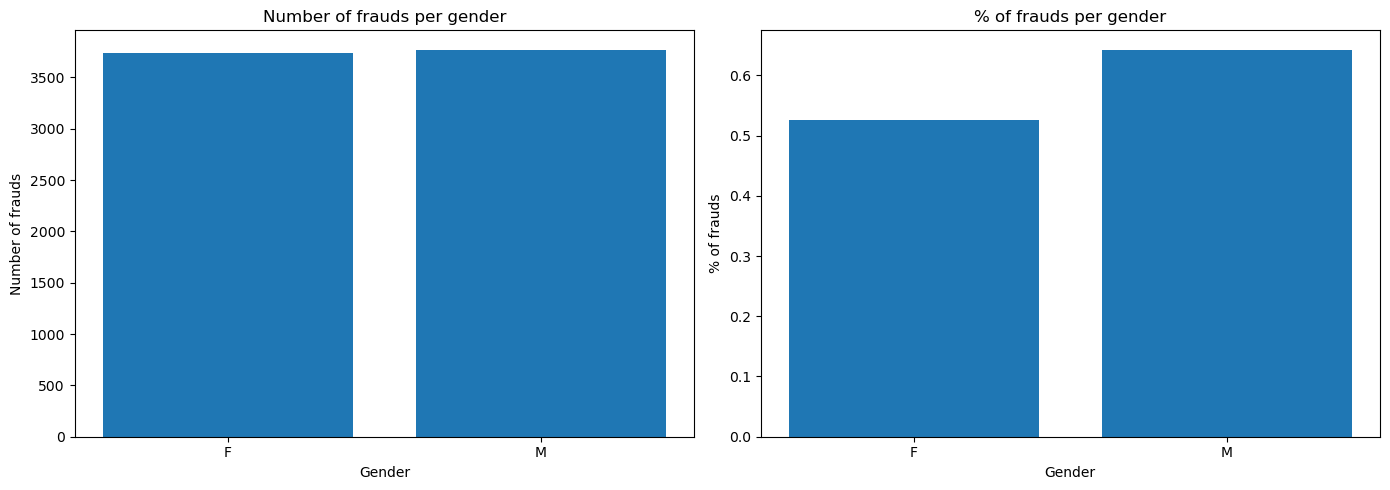

In [14]:
trans_gender = df['gender'].value_counts().sort_index()
fraud_gender = df[df['is_fraud']==1]['gender'].value_counts().sort_index()
perc_gender = (fraud_gender / trans_gender) * 100

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(fraud_gender.index, fraud_gender.values)
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Number of frauds per gender")

ax[1].bar(perc_gender.index, perc_gender.values)
ax[1].set_xlabel("Gender")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("% of frauds per gender")

plt.tight_layout()
plt.show()

Gender carries no predictive signal: the fraud rate is essentially identical across both groups.

We next examine `city_pop`, the population of the cardholder's city of residence.

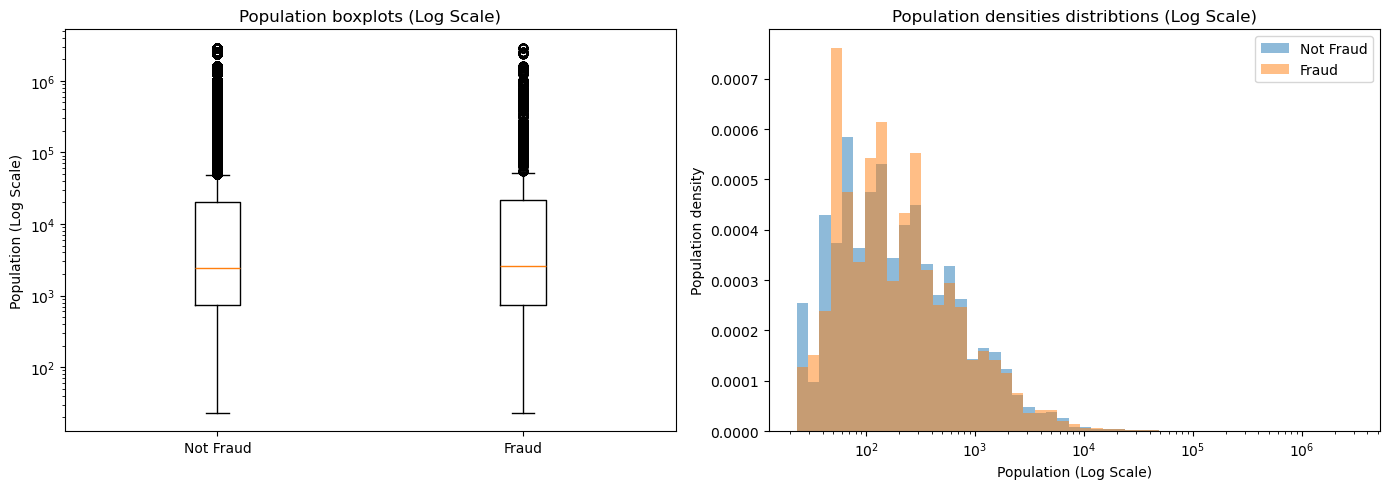

In [15]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([df[df["is_fraud"]==0]["city_pop"], df[df["is_fraud"]==1]["city_pop"]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_yscale("log")
ax[0].set_ylabel("Population (Log Scale)")
ax[0].set_title("Population boxplots (Log Scale)")

bins = np.logspace(np.log10(df['city_pop'].min()), np.log10(df['city_pop'].max()), 50)
ax[1].hist(df[df["is_fraud"]==0]["city_pop"], bins=bins, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(df[df["is_fraud"]==1]["city_pop"], bins=bins, alpha=0.5, label="Fraud", density=True)
ax[1].set_xscale("log")
ax[1].set_xlabel("Population (Log Scale)")
ax[1].set_ylabel("Population density")
ax[1].set_title("Population densities distribtions (Log Scale)")
ax[1].legend()

plt.tight_layout()
plt.show()

The distributions of city population are nearly identical for fraudulent and legitimate transactions — no useful signal here either.

To complete the geographical analysis, we examine fraud rates by US state. We deliberately avoid analysing raw coordinates at finer granularity, as the high dimensionality would introduce noise rather than signal.

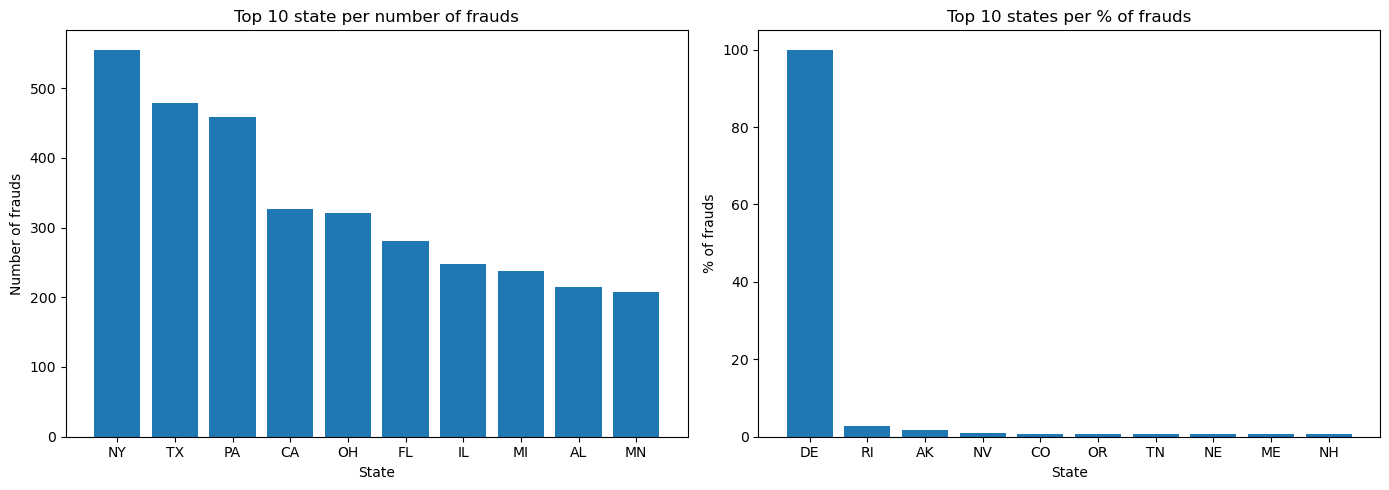

In [16]:
trans_state = df['state'].value_counts()
fraud_state = df[df['is_fraud']==1]['state'].value_counts()

top10_abs = fraud_state.sort_values(ascending=False).head(10)
perc_state = (fraud_state / trans_state * 100).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(top10_abs.index, top10_abs.values)
ax[0].set_xlabel("State")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Top 10 state per number of frauds")

ax[1].bar(perc_state.index, perc_state.values)
ax[1].set_xlabel("State")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("Top 10 states per % of frauds")

plt.tight_layout()
plt.show()

In [17]:
df[df['state']=='DE'][["cc_num","state","is_fraud"]].value_counts()

cc_num            state  is_fraud
6011826317034777  DE     1           9
Name: count, dtype: int64

In absolute terms, no state shows a disproportionately high fraud count. Delaware (DE) appears to stand out in relative terms, but a closer look reveals that a single compromised card accounts for all fraudulent transactions in that state — the same statistical artefact encountered with the 1925 birth year. No geographical feature at any granularity carries actionable signal.

We conclude the EDA by analysing transaction velocity: the time elapsed between consecutive transactions on the same card.

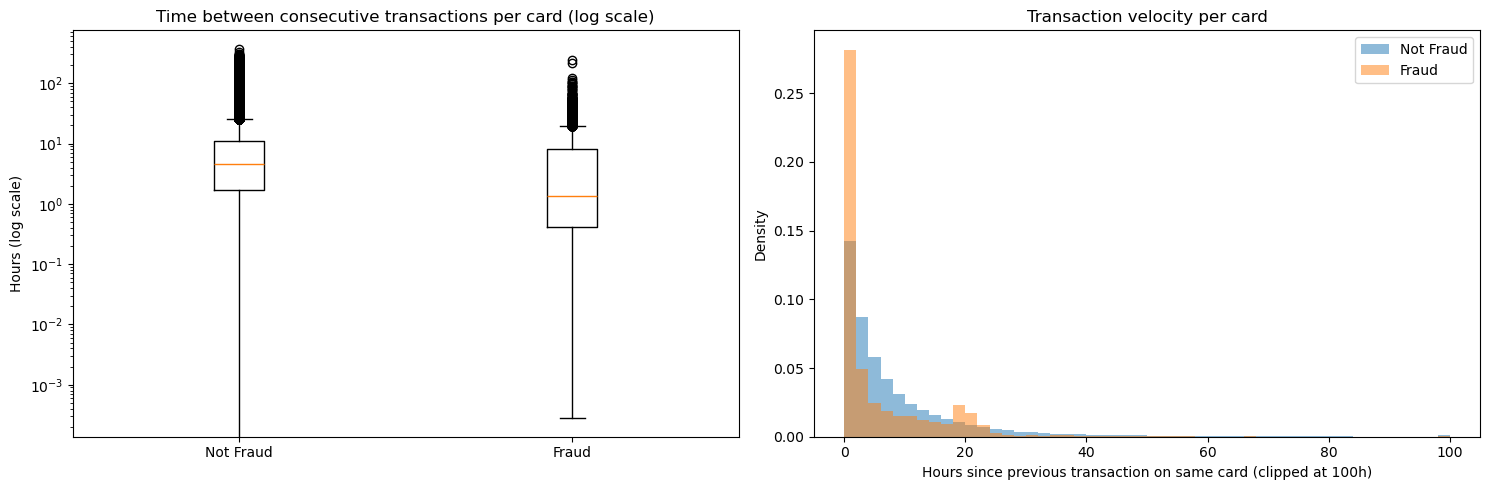

Median hours since last transaction — Not Fraud: 4.6h
Median hours since last transaction — Fraud:     1.4h


In [43]:
df_vel = df[['cc_num', 'unix_time', 'is_fraud']].sort_values(['cc_num', 'unix_time'])
df_vel['hours_since_last'] = df_vel.groupby('cc_num')['unix_time'].diff() / 3600

legit_intervals = df_vel[df_vel['is_fraud'] == 0]['hours_since_last'].dropna()
fraud_intervals = df_vel[df_vel['is_fraud'] == 1]['hours_since_last'].dropna()

clip_h = 100
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

ax[0].boxplot([legit_intervals, fraud_intervals], tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_yscale('log')
ax[0].set_ylabel('Hours (log scale)')
ax[0].set_title('Time between consecutive transactions per card (log scale)')

ax[1].hist(legit_intervals.clip(upper=clip_h), bins=50, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fraud_intervals.clip(upper=clip_h), bins=50, alpha=0.5, label='Fraud', density=True)
ax[1].set_xlabel(f'Hours since previous transaction on same card (clipped at {clip_h}h)')
ax[1].set_ylabel('Density')
ax[1].set_title('Transaction velocity per card')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Median hours since last transaction — Not Fraud: {legit_intervals.median():.1f}h")
print(f"Median hours since last transaction — Fraud:     {fraud_intervals.median():.1f}h")

Fraudulent transactions occur significantly closer together in time than legitimate ones: the median interval drops from 4.6 hours for legitimate transactions to 1.4 hours for fraudulent ones. This is consistent with the typical fraud pattern — a burst of rapid charges once a card is stolen. The time elapsed since the last transaction on the same card (`hours_since_last_trans`) is a strong candidate for feature engineering.

## Feature Engineering - Baseline LogReg

In [ ]:
df_baseline = df.copy()
df_baseline = df_baseline.sort_values(['cc_num', 'unix_time'])

df_baseline['hours_since_last_trans'] = df_baseline.groupby('cc_num')['unix_time'].diff() / 3600

fill_value = df_baseline['hours_since_last_trans'].median()
df_baseline['hours_since_last_trans'] = df_baseline['hours_since_last_trans'].fillna(fill_value)

df_baseline['hour'] = df_baseline['trans_date_trans_time'].dt.hour

cols_to_drop = ['trans_num', 'cc_num', 'first', 'last', 'gender',
                'street', 'city', 'state', 'zip', 'lat', 'long',
                'merch_lat', 'merch_long', 'city_pop', 'job',
                'merchant', 'unix_time', 'dob', 'trans_date_trans_time']

df_baseline = df_baseline.drop(columns=cols_to_drop)

df_baseline = df_baseline.sort_index()

X = df_baseline.drop(columns=['is_fraud'])
y = df_baseline['is_fraud']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

              category     amt  hours_since_last_trans  hour
1037340    grocery_pos   45.16               27.808056     7
1037341    grocery_pos  185.51                7.921111     7
1037342   shopping_pos  122.96                6.118056     7
1037343       misc_pos    1.89                3.478056     7
1037344  entertainment    5.05               60.699444     7


In [69]:
num_features = ['amt', 'hours_since_last_trans', 'hour']
cat_features = ['category']

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('scaler', StandardScaler(), num_features)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

pipe.fit(X_train, y_train)

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


=== Logistic Regression Baseline ===
              precision    recall  f1-score   support

   Not Fraud       1.00      0.88      0.94    257797
       Fraud       0.04      0.76      0.07      1538

    accuracy                           0.88    259335
   macro avg       0.52      0.82      0.50    259335
weighted avg       0.99      0.88      0.93    259335

ROC-AUC : 0.9155
PR-AUC  : 0.1710


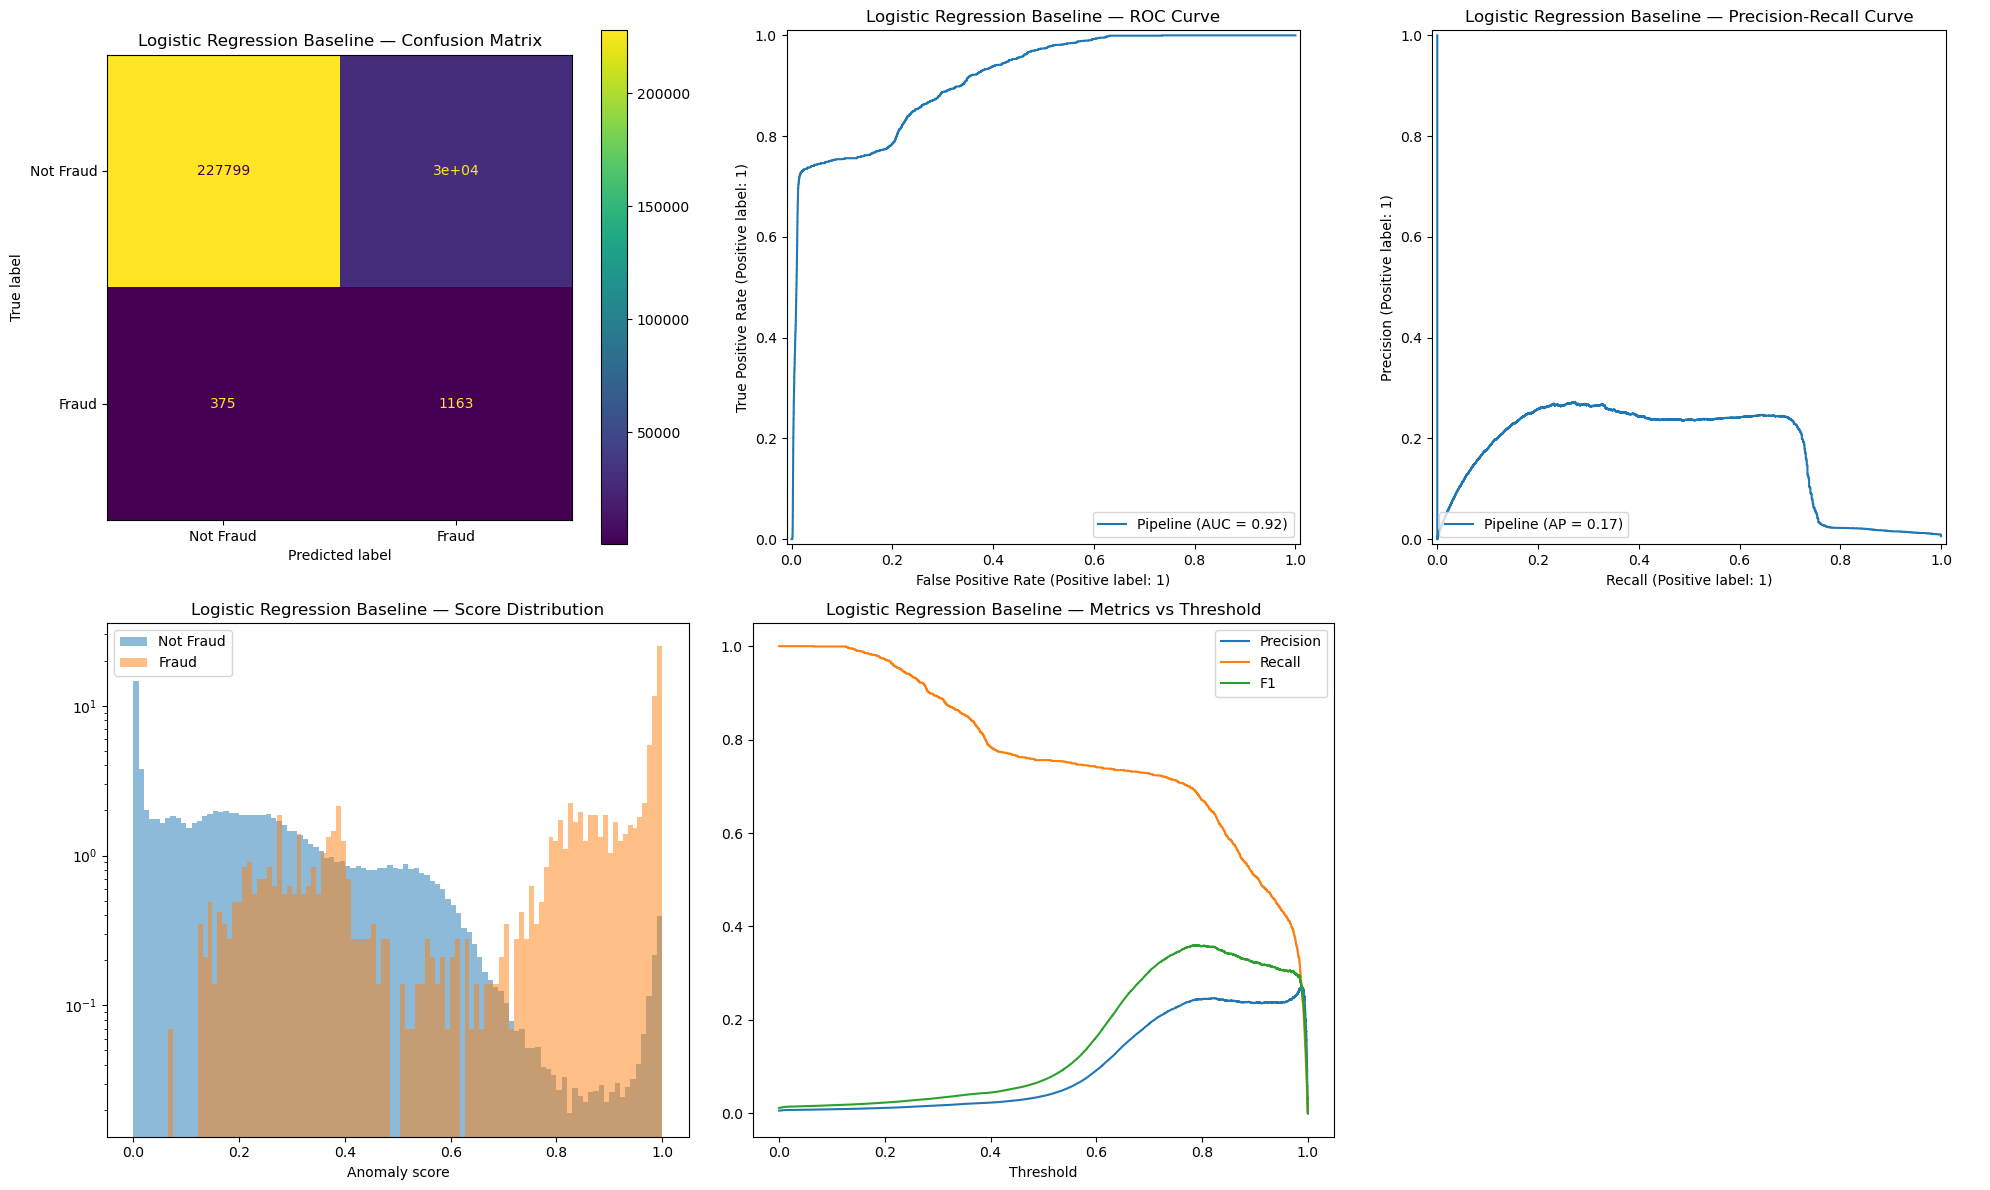

In [74]:
def evaluate_model(model, X_val, y_val, model_name="Model"):
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    print(f"=== {model_name} ===")
    print(classification_report(y_val, y_pred,
                                 target_names=['Not Fraud', 'Fraud']))
    print(f"ROC-AUC : {roc_auc_score(y_val, y_proba):.4f}")
    print(f"PR-AUC  : {average_precision_score(y_val, y_proba):.4f}")

    fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))

    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred, ax=ax[0, 0],
        display_labels=['Not Fraud', 'Fraud'])
    ax[0, 0].set_title(f'{model_name} — Confusion Matrix')

    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax[0, 1])
    ax[0, 1].set_title(f'{model_name} — ROC Curve')

    PrecisionRecallDisplay.from_estimator(model, X_val, y_val, ax=ax[0, 2])
    ax[0, 2].set_title(f'{model_name} — Precision-Recall Curve')

    # score distribution
    ax[1, 0].hist(y_proba[y_val == 0], bins=100, alpha=0.5,
                  label='Not Fraud', density=True)
    ax[1, 0].hist(y_proba[y_val == 1], bins=100, alpha=0.5,
                  label='Fraud', density=True)
    ax[1, 0].set_yscale('log')
    ax[1, 0].set_xlabel('Anomaly score')
    ax[1, 0].set_title(f'{model_name} — Score Distribution')
    ax[1, 0].legend()

    # threshold analysis
    precision, recall, thresholds = precision_recall_curve(y_val, y_proba)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    ax[1, 1].plot(thresholds, precision[:-1], label='Precision')
    ax[1, 1].plot(thresholds, recall[:-1], label='Recall')
    ax[1, 1].plot(thresholds, f1[:-1], label='F1')
    ax[1, 1].set_xlabel('Threshold')
    ax[1, 1].set_title(f'{model_name} — Metrics vs Threshold')
    ax[1, 1].legend()

    ax[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

evaluate_model(pipe, X_val, y_val, "Logistic Regression Baseline")